# 1.8 Independent Three-Way Isoelastic Demand From Gas-Limit Events

This notebook estimates demand for execution, data, and state from the 2025
gas-limit increases. The central specification assumes three independent
isoelastic demand curves:

$$
q_i(p_i) = q_i^0 \left(\frac{p_i}{p_i^0}\right)^{-\epsilon_i},
\qquad i \in \{\text{execution}, \text{data}, \text{state}\}.
$$

Under H0 all three resources pay the same base fee. A gas-limit event therefore
moves every $p_i$ together, and each elasticity can be read directly from its
resource quantity:

$$
\epsilon_i = -\frac{\Delta \ln(q_i/\text{block})}{\Delta \ln p}.
$$

The same result can be reconstructed from aggregate demand, anchor shares, and
the two share-response differences. At the anchor,

$$
\epsilon_{\text{agg}} = \sum_i s_i \epsilon_i,
\qquad
\Delta_i = \epsilon_i - \epsilon_{\text{execution}},
$$

which gives

$$
\epsilon_{\text{execution}} = \epsilon_{\text{agg}}
- s_{\text{data}}\Delta_{\text{data}}
- s_{\text{state}}\Delta_{\text{state}}.
$$

This central model needs no EIP-7623 calibration. Its substantive assumption is
that each resource responds only to its own price. That assumption is useful for
recovering a transparent benchmark, but it omits bundle coupling and cross-price
effects.

## Aggregate-Plus-Softmax Alternative

The earlier flat softmax model is retained as a sensitivity check:

$$
v_i = a_i - \eta_i \ln p_i,
\qquad
s_i = \frac{e^{v_i}}{\sum_j e^{v_j}},
\qquad
T = T_{\text{ref}} \left(\frac{R}{R_{\text{ref}}}\right)^{-\epsilon_{\text{agg}}},
\qquad q_i = s_i T.
$$

One-price events identify $\eta_{\text{data}}-\eta_{\text{execution}}$ and
$\eta_{\text{state}}-\eta_{\text{execution}}$, but not a unique triplet of
$\eta_i$ values. The softmax therefore requires an additional assumption or the
EIP-7623 treated-segment estimate. It is secondary here because that ambiguity is
specific to the softmax construction, not a general limitation of the event data.

## Inputs And Resource Measurements

Everything loads from cached CSVs (offline):

- `gas_limit_data_share_daily_2025-01-01_2026-01-05.csv` (notebook 1.5): daily
  H0 decomposition and fees for 2025.
- `daily_current_data_gas_xatu_2026-01-05_2026-02-01.csv` +
  `daily_accounting_panel_2026-01-05_2026-02-01.csv`: the January 2026 bridge.
- `daily_current_data_gas_xatu_2026-02-01_2026-06-01.csv` +
  `daily_accounting_panel_2026-02-01_2026-06-01.csv`: the February-May 2026
  extension.
- `eip7623_event_state_cleaned_daily_*.csv` (notebook 1.4): Xatu gross
  state-creation gas, used only to validate the state proxy on the overlap.
- `eip7623_event_implied_elasticity_sweep_*.csv` (notebook 1.4): the 7623
  eta values for the sensitivity closure.

Resource quantities (current-rule H0 gas units), identical construction in all
segments:

- `q_data` = charged calldata gas (standard, plus the 7623 floor branch
  post-Pectra);
- `q_execution` = state-cleaned execution gas **including the 21k intrinsic
  gas per transaction** (total block gas minus data minus state). This matches
  the equilibrium accounting downstream (1.7/1.9), where targets count total
  gas; the event responses are insensitive to the convention (pooled deltas
  move by <0.006 vs the body-gas variant);
- `q_state` = CBT **net inventory-delta** proxy: positive daily deltas of
  account count x 25,000 (1.5 used account bytes x 25,000/112 with the same
  112-bytes-per-account convention), storage bytes x 20,000/32, code bytes
  x 200.

Caveats carried from 1.5 and from Maria: the state measurement is a net proxy, not
gross creation, and historical state creation is partly underpriced (e.g. ETH
transfers to new accounts), so the state equation is the weakest of the three.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

try:
    from scipy import stats
    from statsmodels.tsa.ardl import ardl_select_order
    from statsmodels.stats.diagnostic import acorr_ljungbox
    HAVE_STATSMODELS = True
except Exception as exc:
    HAVE_STATSMODELS = False
    STATSMODELS_IMPORT_ERROR = exc

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

pd.options.display.float_format = "{:,.6f}".format
plt.style.use("seaborn-v0_8-whitegrid")

DATA_DIR = PROJECT_ROOT / "data"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

DAILY_CSV = DATA_DIR / "gas_limit_data_share_daily_2025-01-01_2026-01-05.csv"
EXT_DATA_CSVS = [
    DATA_DIR / "daily_current_data_gas_xatu_2026-01-05_2026-02-01.csv",
    DATA_DIR / "daily_current_data_gas_xatu_2026-02-01_2026-06-01.csv",
]
EXT_PANEL_CSVS = [
    DATA_DIR / "daily_accounting_panel_2026-01-05_2026-02-01.csv",
    DATA_DIR / "daily_accounting_panel_2026-02-01_2026-06-01.csv",
]
GROSS_STATE_CSV = DATA_DIR / "eip7623_event_state_cleaned_daily_2025-03-07_2025-07-08.csv"
EIP7623_SWEEP_CSV = DATA_DIR / "eip7623_event_implied_elasticity_sweep_2025-03-07_2025-07-08.csv"
NB15_EVENT_CSV = DATA_DIR / "gas_limit_data_share_event_estimates_2025.csv"

EVENTS = [
    {"event": "30_to_36", "date": pd.Timestamp("2025-02-04"), "note": ""},
    {"event": "36_to_45", "date": pd.Timestamp("2025-07-21"), "note": ""},
    {"event": "45_to_60", "date": pd.Timestamp("2025-11-25"),
     "note": "post window overlaps Fusaka activation (Dec 3) + BPO1 blob expansion (Dec 9)"},
]
WINDOW_DAYS = 35
EXCLUDE_DAYS_AROUND_EVENT = 3
WRITE_CSV = True

OUT_EVENT_CSV = DATA_DIR / "three_way_event_estimates_2025.csv"
OUT_WINDOW_CSV = DATA_DIR / "three_way_window_robustness_2025.csv"
OUT_ARDL_CSV = DATA_DIR / "three_way_daily_ardl_2025.csv"
OUT_ISOELASTIC_CSV = DATA_DIR / "three_way_isoelastic_calibration_2025.csv"
OUT_CLOSURE_CSV = DATA_DIR / "three_way_levels_closures_2025.csv"
OUT_CONSISTENCY_CSV = DATA_DIR / "three_way_consistency_check_2025.csv"

RESOURCES = ["execution", "data", "state"]

# --- 2025 segment (notebook 1.5 panel) ---
d25 = pd.read_csv(DAILY_CSV)
d25["date"] = pd.to_datetime(d25["date"])
d25["q_data"] = d25["data_gas_current"].astype(float)
d25["q_state"] = d25["current_state_inventory_delta_gas_proxy"].astype(float)
# Execution includes the 21k intrinsic gas: total block gas minus data minus
# state, matching the equilibrium accounting (targets count total gas).
d25["q_execution"] = (d25["block_gas_used"].astype(float) - d25["q_data"] - d25["q_state"]).clip(lower=0)
d25["segment"] = "2025_panel"
keep = ["date", "segment", "block_count", "block_gas_used",
        "median_base_fee_per_gas", "gas_limit_mgas",
        "q_execution", "q_data", "q_state"]
d25 = d25[keep]

# --- 2026 extension (Jan bridge + Feb-May data-gas/accounting panels) ---
def read_extension_csvs(paths):
    frames = []
    for path in paths:
        frame = pd.read_csv(path)
        frame["date"] = pd.to_datetime(frame["date"])
        frame["source_file"] = path.name
        frames.append(frame)
    return pd.concat(frames, ignore_index=True, sort=False).sort_values("date").reset_index(drop=True)

ext_data = read_extension_csvs(EXT_DATA_CSVS)
ext_panel = read_extension_csvs(EXT_PANEL_CSVS)
ext = ext_data.merge(
    ext_panel[["date", "median_base_fee_per_gas", "current_gas_used",
               "mean_gas_limit", "accounts_net_delta",
               "storage_bytes_net_delta", "contract_code_bytes_net_delta"]],
    on="date", how="inner", validate="one_to_one",
)
ext["q_data"] = ext["data_gas_current"].astype(float)
ext["q_state"] = (
    ext["accounts_net_delta"].clip(lower=0) * 25_000
    + ext["storage_bytes_net_delta"].clip(lower=0) * (20_000 / 32)
    + ext["contract_code_bytes_net_delta"].clip(lower=0) * 200
)
ext["q_execution"] = (ext["receipt_gas_used"] - ext["q_data"] - ext["q_state"]).clip(lower=0)
ext["block_gas_used"] = ext["receipt_gas_used"]
ext["gas_limit_mgas"] = (ext["mean_gas_limit"] / 1e6).round()
ext["segment"] = "2026_extension"
ext = ext[keep]

daily = pd.concat([d25, ext], ignore_index=True).sort_values("date").reset_index(drop=True)
daily["q_total3"] = daily[["q_execution", "q_data", "q_state"]].sum(axis=1)
for name in RESOURCES:
    daily[f"s_{name}"] = daily[f"q_{name}"] / daily["q_total3"]
daily["log_odds_state"] = np.log(daily["q_state"].replace(0, np.nan) / daily["q_execution"])
daily["log_odds_data"] = np.log(daily["q_data"].replace(0, np.nan) / daily["q_execution"])
daily["log_fee"] = np.log(daily["median_base_fee_per_gas"].astype(float))
daily["gas_per_block"] = daily["block_gas_used"] / daily["block_count"]

gap = daily["date"].diff().dt.days.max()
print(f"days {len(daily)} | {daily['date'].min().date()} -> {daily['date'].max().date()} "
      f"| max gap {gap:.0f} days")

# Splice continuity: the extension state proxy must land on the same scale.
splice = pd.DataFrame([
    {"window": "2025-12 (panel)",
     **{f"{n}_per_block_M": daily.loc[(daily['date'] >= '2025-12-01') & (daily['segment'] == '2025_panel'), f'q_{n}'].sum()
        / daily.loc[(daily['date'] >= '2025-12-01') & (daily['segment'] == '2025_panel'), 'block_count'].sum() / 1e6
        for n in RESOURCES}},
    {"window": "2026-01 bridge",
     **{f"{n}_per_block_M": daily.loc[daily['date'].dt.strftime('%Y-%m') == '2026-01', f'q_{n}'].sum()
        / daily.loc[daily['date'].dt.strftime('%Y-%m') == '2026-01', 'block_count'].sum() / 1e6
        for n in RESOURCES}},
    {"window": "2026-02 extension",
     **{f"{n}_per_block_M": daily.loc[daily['date'].dt.strftime('%Y-%m') == '2026-02', f'q_{n}'].sum()
        / daily.loc[daily['date'].dt.strftime('%Y-%m') == '2026-02', 'block_count'].sum() / 1e6
        for n in RESOURCES}},
])
display(splice)

regime = daily.groupby(["segment", "gas_limit_mgas"]).agg(
    days=("date", "size"),
    median_fee_gwei=("median_base_fee_per_gas", lambda s: s.median() / 1e9),
    s_execution=("s_execution", "mean"),
    s_data=("s_data", "mean"),
    s_state=("s_state", "mean"),
    gas_per_block_M=("gas_per_block", lambda s: s.mean() / 1e6),
)
regime

days 516 | 2025-01-01 -> 2026-05-31 | max gap 1 days


,window,execution_per_block_M,data_per_block_M,state_per_block_M
0,2025-12 (panel),22.015532,0.883427,7.593477
1,2026-01 bridge,21.602368,0.976042,7.801218
2,2026-02 extension,21.727292,1.050750,7.659458


days  median_fee_gwei  s_execution   s_data  \
segment        gas_limit_mgas                                                
2025_panel     30.000000         34         6.293523     0.794024 0.027917   
               36.000000        167         0.758199     0.717626 0.030849   
               45.000000        127         0.270081     0.756916 0.036208   
               60.000000         41         0.038606     0.697055 0.029522   
2026_extension 60.000000        147         0.099129     0.738817 0.037635   

                               s_state  gas_per_block_M  
segment        gas_limit_mgas                            
2025_panel     30.000000      0.178059        15.177647  
               36.000000      0.251525        18.220050  
               45.000000      0.206876        22.724176  
               60.000000      0.273423        30.335811  
2026_extension 60.000000      0.223548        30.366799

### State-Proxy Validation On The 1.4 Overlap

The three-way state measurement is the cheap CBT net-inventory proxy. Before leaning
on it, compare it against notebook 1.4's Xatu gross state-creation gas on the
overlapping days (2025-03-07 to 2025-07-07). Their averages are expected to differ
(net vs gross); what matters for a share regression is co-movement.

In [2]:
gross = pd.read_csv(GROSS_STATE_CSV)
gross["date"] = pd.to_datetime(gross["date"])
gross["gross_state_gas_per_block"] = gross["historical_state_creation_gas"] / gross["block_count"]

overlap = daily.merge(
    gross[["date", "gross_state_gas_per_block"]], on="date", how="inner"
)
overlap["proxy_state_gas_per_block"] = overlap["q_state"] / overlap["block_count"]

proxy_check = pd.DataFrame([{
    "overlap_days": len(overlap),
    "corr_levels": overlap["proxy_state_gas_per_block"].corr(overlap["gross_state_gas_per_block"]),
    "corr_logs": np.log(overlap["proxy_state_gas_per_block"]).corr(np.log(overlap["gross_state_gas_per_block"])),
    "mean_proxy_over_gross": float(
        overlap["proxy_state_gas_per_block"].mean() / overlap["gross_state_gas_per_block"].mean()
    ),
}])
proxy_check

,overlap_days,corr_levels,corr_logs,mean_proxy_over_gross
0,123,0.988203,0.982566,1.282283


## Event-Window Estimates

For each gas-limit increase, pre/post windows of 35 days with 3 event-adjacent
days excluded (same convention as 1.5; window length is stress-tested below).
All quantities are pooled within the window; the fee is the median of daily
medians.

$$
\Delta_i
= -\frac{\Delta \ln (q_i / q_{\text{exec}})}{\Delta \ln p},
\qquad
\epsilon_{\text{agg}}
= -\frac{\Delta \ln (\text{gas per block})}{\Delta \ln p}
$$

Positive $\Delta_i$ means resource $i$'s share (relative to execution) rises
when blockspace gets cheaper, i.e. its share response is larger than execution's.
The per-resource quantity responses $r_i = -\Delta \ln(q_i/\text{block}) /
\Delta \ln p$ are also recorded — the model must reproduce them (consistency
check below).

In [3]:
def event_windows(event_date, window_days=WINDOW_DAYS, exclude_days=EXCLUDE_DAYS_AROUND_EVENT):
    pre_start = event_date - pd.Timedelta(days=exclude_days + window_days)
    pre_end = event_date - pd.Timedelta(days=exclude_days)
    post_start = event_date + pd.Timedelta(days=exclude_days + 1)
    post_end = event_date + pd.Timedelta(days=exclude_days + window_days)
    pre = daily[(daily["date"] >= pre_start) & (daily["date"] < pre_end)]
    post = daily[(daily["date"] >= post_start) & (daily["date"] <= post_end)]
    return pre, post


def pooled_stats(frame):
    blocks = frame["block_count"].sum()
    out = {name: frame[f"q_{name}"].sum() / blocks for name in RESOURCES}
    out["gas_per_block"] = frame["block_gas_used"].sum() / blocks
    out["total3_per_block"] = frame["q_total3"].sum() / blocks
    out["fee"] = frame["median_base_fee_per_gas"].median()
    return out


def event_estimate(spec, window_days=WINDOW_DAYS, exclude_days=EXCLUDE_DAYS_AROUND_EVENT):
    pre, post = event_windows(spec["date"], window_days, exclude_days)
    a, b = pooled_stats(pre), pooled_stats(post)
    dlnp = np.log(b["fee"] / a["fee"])
    return {
        "event": spec["event"],
        "event_date": spec["date"].date().isoformat(),
        "window_days": window_days,
        "exclude_days": exclude_days,
        "pre_days": len(pre),
        "post_days": len(post),
        "dln_fee": dlnp,
        "eps_agg_event": -np.log(b["gas_per_block"] / a["gas_per_block"]) / dlnp,
        "eps_agg_body3_event": -np.log(b["total3_per_block"] / a["total3_per_block"]) / dlnp,
        "delta_state": -(np.log(b["state"] / b["execution"]) - np.log(a["state"] / a["execution"])) / dlnp,
        "delta_data": -(np.log(b["data"] / b["execution"]) - np.log(a["data"] / a["execution"])) / dlnp,
        "r_execution": -np.log(b["execution"] / a["execution"]) / dlnp,
        "r_data": -np.log(b["data"] / a["data"]) / dlnp,
        "r_state": -np.log(b["state"] / a["state"]) / dlnp,
        "pre_s_execution": a["execution"] / a["total3_per_block"],
        "pre_s_data": a["data"] / a["total3_per_block"],
        "pre_s_state": a["state"] / a["total3_per_block"],
        "note": spec["note"],
    }


events = pd.DataFrame([event_estimate(spec) for spec in EVENTS])

# Cross-check against notebook 1.5 (same windows; 1.5 uses body-gas execution,
# so small deviations from delta_data_nb15 are expected under the
# intrinsic-inclusive convention).
if NB15_EVENT_CSV.exists():
    nb15 = pd.read_csv(NB15_EVENT_CSV)[["event", "implied_eta_data"]]
    events = events.merge(nb15.rename(columns={"implied_eta_data": "delta_data_nb15"}), on="event", how="left")

if WRITE_CSV:
    events.to_csv(OUT_EVENT_CSV, index=False)
    print("wrote", OUT_EVENT_CSV)
events.T

wrote /Users/william/PycharmProjects/eip-7999-research/data/three_way_event_estimates_2025.csv


,0,1,2
event,30_to_36,36_to_45,45_to_60
event_date,2025-02-04,2025-07-21,2025-11-25
window_days,35,35,35
exclude_days,3,3,3
pre_days,31,35,35
post_days,35,35,35
dln_fee,-2.114346,-0.886539,-1.254013
eps_agg_event,0.087306,0.251278,0.233533
eps_agg_body3_event,0.087306,0.251278,0.233533
delta_state,0.311313,0.116095,0.233131


### Pooled Central Estimates

The headline pools events 1 and 2 only: event 3's post window overlaps Fusaka
activation and the first BPO blob expansion, which pulls rollup data off
calldata (and shifts composition) independently of the gas-limit price shock.
The all-events pool is reported alongside.

In [4]:
clean = events[events["event"].isin(["30_to_36", "36_to_45"])]
pooled_params = pd.DataFrame([
    {
        "pool": "events_1_2 (headline)",
        "eps_agg": clean["eps_agg_event"].mean(),
        "delta_state": clean["delta_state"].mean(),
        "delta_data": clean["delta_data"].mean(),
    },
    {
        "pool": "all_events",
        "eps_agg": events["eps_agg_event"].mean(),
        "delta_state": events["delta_state"].mean(),
        "delta_data": events["delta_data"].mean(),
    },
])
EPS_AGG = float(pooled_params.loc[0, "eps_agg"])
DELTA_STATE = float(pooled_params.loc[0, "delta_state"])
DELTA_DATA = float(pooled_params.loc[0, "delta_data"])
pooled_params

,pool,eps_agg,delta_state,delta_data
0,events_1_2 (headline),0.169292,0.213704,0.108317
1,all_events,0.190705,0.220180,0.040814


## Window-Length Robustness

The 35-day window is 1.5's convention, not a law. The grid below re-runs the
estimator for windows of 21/35/60/75 days and exclusion buffers of 3/7 days.
Structural constraints on this event calendar:

- **Event 1's pre side is data-capped at ~31 days** (the panel starts
  2025-01-01; a longer pre window needs a Xatu re-query into the late-2024
  bull market, of questionable comparability).
- **Event 3's post side is capped at ~37 days** by the panel end and is
  Fusaka-confounded regardless (it stays out of the headline pool).
- **60 days is the hard ceiling for independence**: at 60d event 2's post
  window ends 2025-09-22 and event 3's pre window starts 2025-09-23 (they
  touch); at 75d they overlap by ~29 days.

Reading the grid:

- $\Delta_{\text{data}}$ is **window-stable** (~0.09–0.12 pooled) — the data
  contrast does not care about the window.
- $\Delta_{\text{state}}$ **decays with horizon** (~0.37 at 21d, ~0.21 at 35d,
  ~0.16–0.19 at 60d): the state-share response is front-loaded and partially
  transient, consistent with the daily ARDL's cumulative-vs-long-run gap. For
  fee-market design the settled (60d) end is arguably the relevant one, so
  $\Delta_{\text{state}}$ should be read as a range, not a point.
- $\epsilon_{\text{agg}}$ **falls with window length** (0.17 at 35d, ~0.13 at
  60d) — but not because longer is cleaner: the base fee keeps sliding within
  a regime for months as demand grows into the new capacity, so long windows
  attribute regime drift to the event. For the aggregate elasticity the
  21–35d designs are the cleaner ones.

In [5]:
window_rows = []
for window_days in [21, 35, 60, 75]:
    for exclude_days in [3, 7]:
        for spec in EVENTS:
            row = event_estimate(spec, window_days, exclude_days)
            if row["pre_days"] < 10 or row["post_days"] < 10:
                continue
            window_rows.append({k: row[k] for k in [
                "window_days", "exclude_days", "event", "pre_days", "post_days",
                "dln_fee", "eps_agg_event", "delta_state", "delta_data"]})
window_grid = pd.DataFrame(window_rows)

pooled_by_design = (
    window_grid[window_grid["event"].isin(["30_to_36", "36_to_45"])]
    .groupby(["window_days", "exclude_days"])[["eps_agg_event", "delta_state", "delta_data"]]
    .mean()
    .rename(columns={"eps_agg_event": "eps_agg"})
)
if WRITE_CSV:
    window_grid.to_csv(OUT_WINDOW_CSV, index=False)
    print("wrote", OUT_WINDOW_CSV)
display(pooled_by_design)
window_grid

wrote /Users/william/PycharmProjects/eip-7999-research/data/three_way_window_robustness_2025.csv


eps_agg  delta_state  delta_data
window_days exclude_days                                  
21          3            0.194893     0.361371    0.084723
            7            0.219161     0.324963    0.062452
35          3            0.169292     0.213704    0.108317
            7            0.170799     0.212706    0.098483
60          3            0.127086     0.198007    0.123023
            7            0.131791     0.168137    0.116282
75          3            0.119173     0.175045    0.122880
            7            0.129247     0.136439    0.124398

,window_days,exclude_days,event,pre_days,post_days,dln_fee,eps_agg_event,delta_state,delta_data
0,21,3,30_to_36,21,21,-1.799915,0.101821,0.409536,0.094914
1,21,3,36_to_45,21,21,-0.772616,0.287966,0.313206,0.074532
2,21,3,45_to_60,21,21,-1.519226,0.193840,0.255636,-0.136482
3,21,7,30_to_36,21,21,-2.050123,0.090169,0.376869,0.110009
4,21,7,36_to_45,21,21,-0.641389,0.348154,0.273058,0.014895
5,21,7,45_to_60,21,21,-1.447900,0.203515,0.150700,-0.178719
6,35,3,30_to_36,31,35,-2.114346,0.087306,0.311313,0.116765
7,35,3,36_to_45,35,35,-0.886539,0.251278,0.116095,0.099868
8,35,3,45_to_60,35,35,-1.254013,0.233533,0.233131,-0.094191
9,35,7,30_to_36,27,35,-2.181279,0.085190,0.346176,0.126775


## Daily ARDL Robustness (Share Equations Only)

Full-sample daily first-difference ARDL with HAC errors and contiguous-lag AIC order selection for the two log-odds
measurements, mirroring 1.5's method, run on the 2025 panel alone and on the
extended sample (2025 panel + January bridge + February-May extension). Diffs
are guarded against any date gaps, but with the bridge present the sample is
calendar-continuous. The aggregate equation is **not** estimated from dailies:
EIP-1559 makes the fee a mechanical function of recent gas use, so daily
fee/gas co-movement is simultaneity, not demand response — the aggregate
elasticity comes from the event windows only.

In [6]:
def ardl_cumulative(series_name, frame, sample_label):
    work = frame[["date", "segment", series_name, "log_fee"]].copy()
    work["dy"] = work[series_name].diff()
    work["dx"] = work["log_fee"].diff()
    seam = work["date"].diff().dt.days > 1
    work.loc[seam, ["dy", "dx"]] = np.nan
    work = work.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    sel = ardl_select_order(work["dy"], 10, work[["dx"]], 10, ic="aic", trend="c", causal=False, glob=False)
    res = sel.model.fit(cov_type="HAC", cov_kwds={"maxlags": 10})
    names = list(res.params.index)
    beta = np.array([1.0 if name.startswith("dx") else 0.0 for name in names])
    phi = np.array([1.0 if name.startswith("dy") else 0.0 for name in names])
    theta, cov = res.params.values, res.cov_params().values
    s_sum, own_sum = float(beta @ theta), float(phi @ theta)
    se = float(np.sqrt(beta @ cov @ beta))
    crit = stats.t.ppf(0.975, res.df_resid)
    lb = acorr_ljungbox(res.resid, lags=[30], model_df=res.df_model)
    return {
        "series": series_name,
        "sample": sample_label,
        "selected_order": str(sel.model.ardl_order),
        "nobs": int(res.nobs),
        "delta_cumulative": -s_sum,
        "delta_ci_low": -(s_sum + crit * se),
        "delta_ci_high": -(s_sum - crit * se),
        "delta_longrun": -s_sum / (1 - own_sum) if (1 - own_sum) != 0 else np.nan,
        "ljung_box_lag30_pvalue": float(lb["lb_pvalue"].values[0]),
    }


if HAVE_STATSMODELS:
    frames = {
        "2025_panel": daily[daily["segment"] == "2025_panel"],
        "extended": daily,
    }
    ardl_summary = pd.DataFrame([
        ardl_cumulative(series, frame, label)
        for series in ["log_odds_data", "log_odds_state"]
        for label, frame in frames.items()
    ])
else:
    ardl_summary = pd.DataFrame([{"series": "unavailable", "error": repr(STATSMODELS_IMPORT_ERROR)}])
if WRITE_CSV:
    ardl_summary.to_csv(OUT_ARDL_CSV, index=False)
ardl_summary

,series,sample,selected_order,nobs,delta_cumulative,delta_ci_low,delta_ci_high,delta_longrun,ljung_box_lag30_pvalue
0,log_odds_data,2025_panel,"(7, 7)",361,0.404159,0.260523,0.547794,0.138025,0.001634
1,log_odds_data,extended,"(10, 7)",505,0.310216,0.199695,0.420737,0.104936,0.006260
2,log_odds_state,2025_panel,"(7, 6)",361,1.075158,0.681498,1.468818,0.492650,0.000013
3,log_odds_state,extended,"(7, 6)",508,1.064641,0.756534,1.372749,0.478016,0.000000


## Independent Isoelastic Calibration (Central)

The 45M pre-Fusaka anchor supplies the resource shares. Combining those shares
with the clean-event estimates gives

$$
\epsilon_{\text{execution}} = \epsilon_{\text{agg}}
- s_{\text{data}}\Delta_{\text{data}}
- s_{\text{state}}\Delta_{\text{state}},
\qquad
\epsilon_i = \epsilon_{\text{execution}} + \Delta_i.
$$

The notebook also compares this share-weighted reconstruction with the direct
mean of each resource's event response. The two calculations differ only because
the reconstruction averages the event parameters before applying fixed anchor
shares, while the direct calculation averages the two finite event responses.

## Aggregate-Plus-Softmax Sensitivity

For the softmax alternative, the event-identified $\eta$ differences do not
select a unique $\eta$ triplet. We therefore sweep $\eta_{\text{execution}}$
and separately import the EIP-7623 data estimate. At the common-price H0 anchor,
the aggregate price-index weights are set equal to measured resource gas shares,
$w_i=s_i$, so the implied own-price elasticity is

$$
\epsilon_i = \eta_i (1 - s_i) + \epsilon_{\text{agg}} s_i.
$$

EIP-7623 raised the floor-bound calldata charge from 4/16 to 10/40 gas per
zero/nonzero byte, a theoretical 2.5x shock. Including intrinsic and execution
gas, notebook 1.4 measures an effective treated-transaction price ratio of
$2.1119$. Over the 60-day pre/post windows, the main treated calldata share falls
from 0.467% to 0.366%, giving

$$
\eta_{\text{data}}^{7623}
=-\frac{\operatorname{logit}(0.003664)-\operatorname{logit}(0.004671)}
{\ln(2.1119)}
=0.326.
$$

After subtracting estimated state-creation gas from the execution denominator,
the corresponding share falls from 0.654% to 0.475%, giving

$$
\eta_{\text{data, state-cleaned}}^{7623}
=-\frac{\operatorname{logit}(0.004750)-\operatorname{logit}(0.006536)}
{\ln(2.1119)}
=0.429.
$$

Both enter only as softmax sensitivities because the surviving floor-bound group
is ~1.8% of pre-fork transactions and may change composition after the fork.

In [7]:
anchor = daily[(daily["segment"] == "2025_panel") & (daily["gas_limit_mgas"] == 45.0)]
S = {name: float(anchor[f"s_{name}"].mean()) for name in RESOURCES}
print("anchor shares (45M regime):", {k: round(v, 4) for k, v in S.items()})


def isoelastic_row(window_days, triplet):
    eps_agg = float(triplet["eps_agg"])
    delta_data = float(triplet["delta_data"])
    delta_state = float(triplet["delta_state"])
    eps_execution = eps_agg - S["data"] * delta_data - S["state"] * delta_state
    return {
        "model": "independent_isoelastic",
        "window_days": window_days,
        "exclude_days": 3,
        "eps_agg": eps_agg,
        "delta_data": delta_data,
        "delta_state": delta_state,
        **{f"s_{name}_anchor": S[name] for name in RESOURCES},
        "eps_execution": eps_execution,
        "eps_data": eps_execution + delta_data,
        "eps_state": eps_execution + delta_state,
    }


isoelastic_calibrations = pd.DataFrame([
    isoelastic_row(window_days, pooled_by_design.loc[(window_days, 3)])
    for window_days in [21, 35, 60, 75]
])
iso35 = isoelastic_calibrations.set_index("window_days").loc[35]
direct_means = {name: float(clean[f"r_{name}"].mean()) for name in RESOURCES}
direct_vs_reconstructed = pd.DataFrame([
    {"resource": name,
     "direct_mean_of_event_elasticities": direct_means[name],
     "aggregate_plus_gaps_reconstruction": float(iso35[f"eps_{name}"]),
     "difference": direct_means[name] - float(iso35[f"eps_{name}"])}
    for name in RESOURCES
])
if WRITE_CSV:
    isoelastic_calibrations.to_csv(OUT_ISOELASTIC_CSV, index=False)
display(isoelastic_calibrations)
display(direct_vs_reconstructed)


def closure_row(eta_exec, label):
    eta = {
        "execution": eta_exec,
        "data": eta_exec + DELTA_DATA,
        "state": eta_exec + DELTA_STATE,
    }
    row = {"closure": label, "eta_execution": eta["execution"],
           "eta_data": eta["data"], "eta_state": eta["state"],
           "eta_negative": any(v < 0 for v in eta.values())}
    for name in RESOURCES:
        row[f"eps_{name}"] = eta[name] * (1 - S[name]) + EPS_AGG * S[name]
    return row


rows = [closure_row(v, f"A: sweep eta_exec={v:.2f}") for v in [0.0, 0.05, 0.1, 0.2, 0.3, 0.5]]

eta_7623 = pd.read_csv(EIP7623_SWEEP_CSV)
for label, key in [("B: 7623 main (0.326)", "main long-window effective eta"),
                   ("B: 7623 state-cleaned (0.429)", "state-cleaned long-window effective eta")]:
    eta_data_value = float(eta_7623.loc[eta_7623["interpretation"].eq(key), "eta_data"].iloc[0])
    rows.append(closure_row(eta_data_value - DELTA_DATA, label))

closures = pd.DataFrame(rows)
if WRITE_CSV:
    closures.to_csv(OUT_CLOSURE_CSV, index=False)
closures

anchor shares (45M regime): {'execution': 0.7569, 'data': 0.0362, 'state': 0.2069}


,model,window_days,exclude_days,eps_agg,delta_data,delta_state,s_execution_anchor,s_data_anchor,s_state_anchor,eps_execution,eps_data,eps_state
0,independent_isoelastic,21,3,0.194893,0.084723,0.361371,0.756916,0.036208,0.206876,0.117067,0.201790,0.478438
1,independent_isoelastic,35,3,0.169292,0.108317,0.213704,0.756916,0.036208,0.206876,0.121160,0.229476,0.334864
2,independent_isoelastic,60,3,0.127086,0.123023,0.198007,0.756916,0.036208,0.206876,0.081668,0.204691,0.279676
3,independent_isoelastic,75,3,0.119173,0.122880,0.175045,0.756916,0.036208,0.206876,0.078511,0.201391,0.253556


,resource,direct_mean_of_event_elasticities,aggregate_plus_gaps_reconstruction,difference
0,execution,0.116901,0.121160,-0.004259
1,data,0.225218,0.229476,-0.004259
2,state,0.330605,0.334864,-0.004259


,closure,eta_execution,eta_data,eta_state,eta_negative,eps_execution,eps_data,eps_state
0,A: sweep eta_exec=0.00,0.000000,0.108317,0.213704,False,0.128140,0.110524,0.204516
1,A: sweep eta_exec=0.05,0.050000,0.158317,0.263704,False,0.140294,0.158714,0.244173
2,A: sweep eta_exec=0.10,0.100000,0.208317,0.313704,False,0.152448,0.206904,0.283829
3,A: sweep eta_exec=0.20,0.200000,0.308317,0.413704,False,0.176756,0.303283,0.363141
4,A: sweep eta_exec=0.30,0.300000,0.408317,0.513704,False,0.201065,0.399662,0.442454
5,A: sweep eta_exec=0.50,0.500000,0.608317,0.713704,False,0.249682,0.592421,0.601078
6,B: 7623 main (0.326),0.217919,0.326236,0.431623,False,0.181112,0.320553,0.377353
7,B: 7623 state-cleaned (0.429),0.321101,0.429418,0.534805,False,0.206194,0.419999,0.459189


## Model Reconstruction Check

For the softmax alternative, the predicted per-resource response to a common
fee move does not depend on the selected $\eta$ triplet:

$$
r_i^{\text{pred}}
= \epsilon_{\text{agg}} + \eta_i - \bar{\eta},
\qquad
\bar{\eta} = \sum_j s_j \eta_j
$$

Comparing both models with the direct event responses shows the small numerical
difference caused by averaging the two events before reconstruction.

In [8]:
eta_bar_minus_exec = S["data"] * DELTA_DATA + S["state"] * DELTA_STATE
softmax_predicted = {
    name: EPS_AGG + {"execution": 0.0, "data": DELTA_DATA, "state": DELTA_STATE}[name] - eta_bar_minus_exec
    for name in RESOURCES
}
isoelastic_predicted = {name: float(iso35[f"eps_{name}"]) for name in RESOURCES}
measured = {name: float(clean[f"r_{name}"].mean()) for name in RESOURCES}
consistency = pd.DataFrame([
    {"model": model, "resource": name,
     "measured_r_events_1_2": measured[name],
     "predicted_r_model": predicted[name],
     "gap": measured[name] - predicted[name]}
    for model, predicted in [("independent_isoelastic", isoelastic_predicted),
                             ("aggregate_plus_softmax", softmax_predicted)]
    for name in RESOURCES
])
if WRITE_CSV:
    consistency.to_csv(OUT_CONSISTENCY_CSV, index=False)
consistency

,model,resource,measured_r_events_1_2,predicted_r_model,gap
0,independent_isoelastic,execution,0.116901,0.121160,-0.004259
1,independent_isoelastic,data,0.225218,0.229476,-0.004259
2,independent_isoelastic,state,0.330605,0.334864,-0.004259
3,aggregate_plus_softmax,execution,0.116901,0.121160,-0.004259
4,aggregate_plus_softmax,data,0.225218,0.229476,-0.004259
5,aggregate_plus_softmax,state,0.330605,0.334864,-0.004259


## Plots

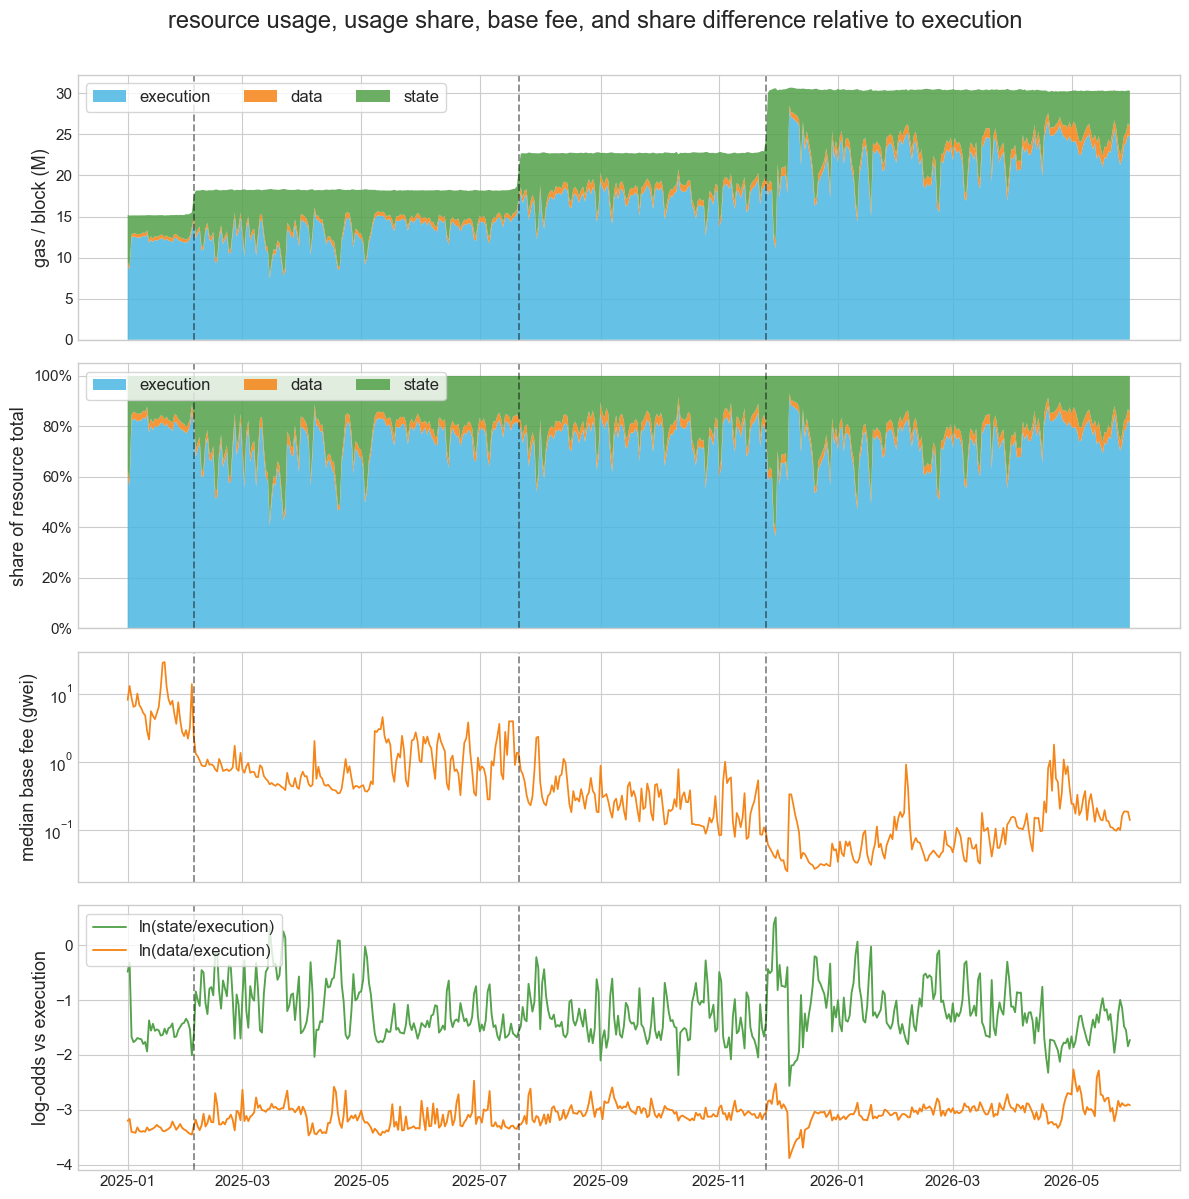

In [9]:
RESOURCE_COLORS = {
    "execution": "#4CB7E1",  # sky blue
    "data": "#F58518",
    "state": "#54A24B",
}
LABEL_FONTSIZE = 13
TICK_FONTSIZE = 11
LEGEND_FONTSIZE = 12
TITLE_FONTSIZE = 17

fig, axes = plt.subplots(
    4, 1,
    figsize=(12, 12),
    sharex=True,
    gridspec_kw={"height_ratios": [1.15, 1.15, 1.0, 1.15]},
)

# Absolute resource usage per block.
axes[0].stackplot(
    daily["date"],
    daily["q_execution"] / daily["block_count"] / 1e6,
    daily["q_data"] / daily["block_count"] / 1e6,
    daily["q_state"] / daily["block_count"] / 1e6,
    labels=["execution", "data", "state"],
    alpha=0.86,
    colors=[RESOURCE_COLORS["execution"], RESOURCE_COLORS["data"], RESOURCE_COLORS["state"]],
)
axes[0].set_ylabel("gas / block (M)", fontsize=LABEL_FONTSIZE)
axes[0].legend(loc="upper left", ncols=3, fontsize=LEGEND_FONTSIZE, frameon=True)

# Resource usage shares.
axes[1].stackplot(
    daily["date"],
    daily["s_execution"],
    daily["s_data"],
    daily["s_state"],
    labels=["execution", "data", "state"],
    alpha=0.86,
    colors=[RESOURCE_COLORS["execution"], RESOURCE_COLORS["data"], RESOURCE_COLORS["state"]],
)
axes[1].set_ylabel("share of resource total", fontsize=LABEL_FONTSIZE)
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1].legend(loc="upper left", ncols=3, fontsize=LEGEND_FONTSIZE, frameon=True)

# Base fee.
axes[2].plot(
    daily["date"],
    daily["median_base_fee_per_gas"] / 1e9,
    color="#F58518",
    linewidth=1.25,
)
axes[2].set_ylabel("median base fee (gwei)", fontsize=LABEL_FONTSIZE)
axes[2].set_yscale("log")

# Share differences relative to execution.
axes[3].plot(
    daily["date"],
    daily["log_odds_state"],
    linewidth=1.35,
    label="ln(state/execution)",
    color=RESOURCE_COLORS["state"],
)
axes[3].plot(
    daily["date"],
    daily["log_odds_data"],
    linewidth=1.35,
    label="ln(data/execution)",
    color=RESOURCE_COLORS["data"],
)
axes[3].set_ylabel("log-odds vs execution", fontsize=LABEL_FONTSIZE)
axes[3].legend(loc="upper left", fontsize=LEGEND_FONTSIZE, frameon=True)

for ax in axes:
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)
    for spec in EVENTS:
        ax.axvline(spec["date"], linestyle="--", color="black", alpha=0.45, linewidth=1.35)

fig.suptitle(
    "resource usage, usage share, base fee, and share difference relative to execution",
    fontsize=TITLE_FONTSIZE,
    y=0.995,
)
fig.tight_layout(rect=[0, 0, 1, 0.985])
fig.savefig(PLOTS_DIR / "three_way_shares_2025.png", dpi=180)
plt.show()

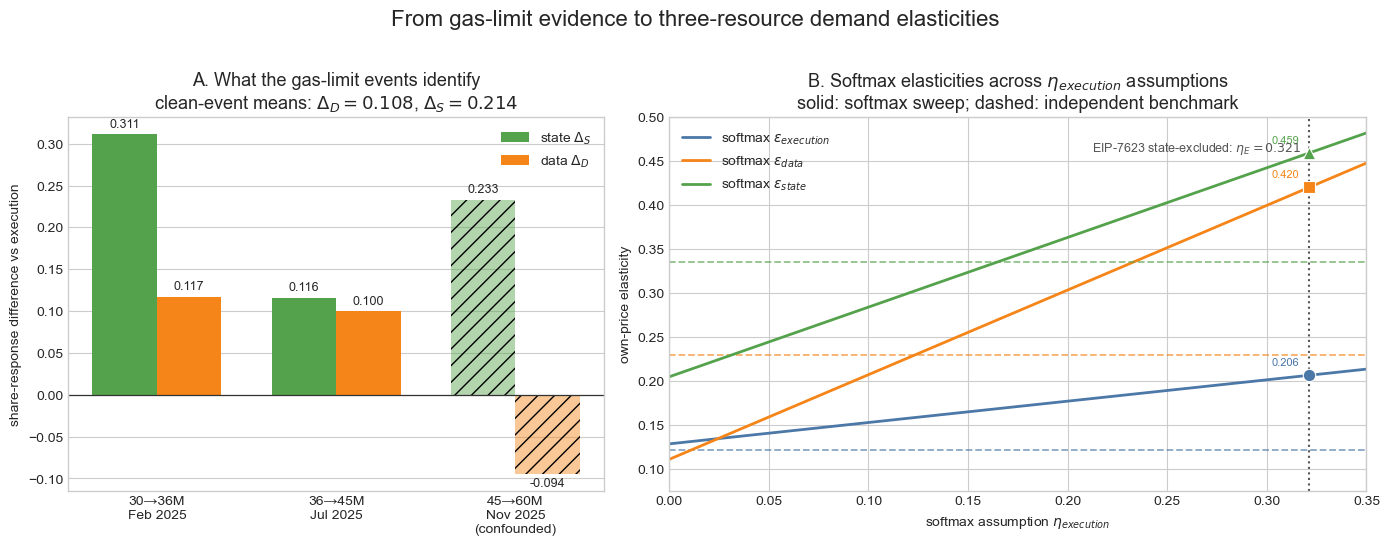

eta_execution   0.321101
eta_data        0.429418
eta_state       0.534805
eps_execution   0.206194
eps_data        0.419999
eps_state       0.459189
Name: 7, dtype: object

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.3), gridspec_kw={"width_ratios": [1.0, 1.3]})

# Panel A: reduced-form evidence from each gas-limit event.
x = np.arange(len(events))
width = 0.36
bars_state = axes[0].bar(
    x - width / 2, events["delta_state"], width,
    label=r"state $\Delta_S$", color="#54A24B",
)
bars_data = axes[0].bar(
    x + width / 2, events["delta_data"], width,
    label=r"data $\Delta_D$", color="#F58518",
)
for bar in [bars_state[-1], bars_data[-1]]:
    bar.set_alpha(0.45)
    bar.set_hatch("//")
axes[0].axhline(0, color="#333333", linewidth=0.9)
axes[0].bar_label(bars_state, fmt="%.3f", padding=3, fontsize=9)
axes[0].bar_label(bars_data, fmt="%.3f", padding=3, fontsize=9)
axes[0].set_xticks(x, ["30→36M\nFeb 2025", "36→45M\nJul 2025", "45→60M\nNov 2025\n(confounded)"])
axes[0].set_ylabel("share-response difference vs execution")
axes[0].set_title(
    "A. What the gas-limit events identify\n"
    r"clean-event means: $\Delta_D=0.108$, $\Delta_S=0.214$",
    fontsize=13,
)
axes[0].legend(loc="upper right", frameon=False)
axes[0].grid(axis="x", visible=False)

# Panel B: continuous softmax sensitivity, with the selected EIP-7623 anchor.
eta_exec_grid = np.linspace(0.0, 0.35, 141)
resource_style = {
    "execution": {"color": "#4C78A8", "marker": "o"},
    "data": {"color": "#F58518", "marker": "s"},
    "state": {"color": "#54A24B", "marker": "^"},
}
delta_by_resource = {"execution": 0.0, "data": DELTA_DATA, "state": DELTA_STATE}
softmax_curves = {}
for name, style in resource_style.items():
    eta_i = eta_exec_grid + delta_by_resource[name]
    eps_i = eta_i * (1 - S[name]) + EPS_AGG * S[name]
    softmax_curves[name] = eps_i
    axes[1].plot(eta_exec_grid, eps_i, color=style["color"], linewidth=2.0,
                 label=rf"softmax $\epsilon_{{{name}}}$")
    axes[1].axhline(float(iso35[f"eps_{name}"]), color=style["color"],
                    linestyle="--", linewidth=1.3, alpha=0.65)

softmax_state_cleaned = closures.loc[
    closures["closure"].eq("B: 7623 state-cleaned (0.429)")
].iloc[0]
eta_exec_state_cleaned = float(softmax_state_cleaned["eta_execution"])
axes[1].axvline(eta_exec_state_cleaned, color="#555555", linestyle=":", linewidth=1.5)
for name, style in resource_style.items():
    eps_value = float(softmax_state_cleaned[f"eps_{name}"])
    axes[1].scatter(eta_exec_state_cleaned, eps_value, s=80, color=style["color"],
                    marker=style["marker"], edgecolor="white", linewidth=0.8, zorder=4)
    axes[1].annotate(f"{eps_value:.3f}", (eta_exec_state_cleaned, eps_value),
                     xytext=(-7, 7), textcoords="offset points", ha="right",
                     fontsize=8, color=style["color"])
axes[1].annotate(
    r"EIP-7623 state-excluded: $\eta_E=0.321$",
    xy=(eta_exec_state_cleaned, 0.475), xytext=(-5, 0), textcoords="offset points",
    ha="right", va="top", fontsize=9, color="#555555",
)
axes[1].set_xlim(0.0, 0.35)
axes[1].set_ylim(0.075, 0.50)
axes[1].set_xlabel(r"softmax assumption $\eta_{execution}$")
axes[1].set_ylabel("own-price elasticity")
axes[1].set_title(
    r"B. Softmax elasticities across $\eta_{execution}$ assumptions" "\n"
    "solid: softmax sweep; dashed: independent benchmark",
    fontsize=13,
)
axes[1].legend(loc="upper left", frameon=False)

fig.suptitle("From gas-limit evidence to three-resource demand elasticities", fontsize=16, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "three_way_levels_sweep_2025.png", dpi=180, bbox_inches="tight")
plt.show()
softmax_state_cleaned[["eta_execution", "eta_data", "eta_state",
                         "eps_execution", "eps_data", "eps_state"]]

## Comparison Against The Nested Model

The table places the independent isoelastic calibration beside the earlier
nested recovery and the aggregate-plus-softmax sensitivities. The central
isoelastic row is identified internally from the clean gas-limit events and
the 45M anchor shares; the other rows require additional structure or inputs.

In [11]:
nested_reference = pd.DataFrame([
    {"model": "nested (Maria + 7623 prior)", "eps_execution": 0.057, "eps_data": 0.487, "eps_state": 0.510},
])
isoelastic_reference = pd.DataFrame([{
    "model": "independent isoelastic (35d clean events)",
    **{f"eps_{name}": float(iso35[f"eps_{name}"]) for name in RESOURCES},
}])
direct_rows = closures[["closure", "eps_execution", "eps_data", "eps_state"]].copy()
direct_rows = direct_rows.rename(columns={"closure": "model"})
comparison = pd.concat([isoelastic_reference, nested_reference, direct_rows], ignore_index=True)
comparison

,model,eps_execution,eps_data,eps_state
0,independent isoelastic (35d clean events),0.121160,0.229476,0.334864
1,nested (Maria + 7623 prior),0.057000,0.487000,0.510000
2,A: sweep eta_exec=0.00,0.128140,0.110524,0.204516
3,A: sweep eta_exec=0.05,0.140294,0.158714,0.244173
4,A: sweep eta_exec=0.10,0.152448,0.206904,0.283829
5,A: sweep eta_exec=0.20,0.176756,0.303283,0.363141
6,A: sweep eta_exec=0.30,0.201065,0.399662,0.442454
7,A: sweep eta_exec=0.50,0.249682,0.592421,0.601078
8,B: 7623 main (0.326),0.181112,0.320553,0.377353
9,B: 7623 state-cleaned (0.429),0.206194,0.419999,0.459189


## Provenance And Independence

What the central results do and do not depend on:

- **Central estimates (eps_agg, Delta_state, Delta_data, the three independent
  elasticities, ARDL, and window grid)**
  are computed from raw Xatu/CBT daily quantities and observed base fees only.
  The construction rules (7623 floor branch for charged data gas, state-cleaned
  execution, current-rule state conversion rates 25,000 / 20,000-per-32B / 200)
  are protocol accounting, not estimated parameters. **No value from Maria's
  analysis or from notebooks 1.4/1.6 enters these numbers.** That eps_agg
  lands near Maria's 0.175 is an independent replication, not an input.
- **The softmax EIP-7623 calibration** imports notebook 1.4's treated-segment
  estimate by design and is labelled as a high-response sensitivity.
- **Maria's numbers appear only in the comparison table** as a display row.
- **Notebook 1.4's gross state measurement** is used only to validate the state
  proxy (correlation check), not in any estimate.

## How To Read This

- **Central result**: assuming independent isoelastic demands, the clean events
  identify execution, data, and state elasticities without an external input.
- **Secondary result**: the aggregate-plus-softmax model needs an extra
  assumption because one-price data do not select a unique $\eta$ triplet.
  The EIP-7623 treated segment supplies a high-response sensitivity.
- **Window choice**: 35d headline for comparability with 1.5; the grid shows
  Delta_data is window-stable, Delta_state decays toward ~0.16-0.19 at 60d
  (report as a range), and eps_agg is cleanest at 21-35d (long windows absorb
  within-regime fee drift).
- **The state equation is the weak leg**: net-inventory proxy instead of gross
  creation, and Maria's warning that historically underpriced state creation
  biases the measured response.
- **Event 3 is Fusaka/BPO-confounded** and excluded from the headline pool.
- The 2026 bridge/extension adds no gas-limit events; it affects only the
  extended-sample ARDL, the regime table, and the plots.
- Independent demand omits transaction-bundle coupling and cross-price effects.
  Post-7999 data with separately moving prices would test that assumption and
  directly estimate those channels.